# autogluon residual method

In [1]:
import pandas as pd
import numpy as np
import nucml.datasets as nuc_data
from autogluon.tabular import TabularPredictor
import matplotlib.pyplot as plt
import os

# Set global target
target_iso = '241Am'

/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 1. Load EXFOR (Reaction Data)
exfor_df = nuc_data.load_exfor()
exfor_df['MT'] = pd.to_numeric(exfor_df['MT'], errors='coerce')
# Filter for Fission (18) and Actinides (Z >= 89)
actinides = exfor_df[(exfor_df['MT'] == 18) & (exfor_df['Z'] >= 89)].copy()

# 2. Load RIPL/ENSDF (Nuclear Structure)
ensdf_ml, _, _, _, _, _, _ = nuc_data.load_ensdf_ml(cutoff=False, append_ame=True, basic=1, num=True)
ripl_grouped = ensdf_ml.groupby(['Z', 'A']).mean().reset_index()

# 3. Merge EXFOR + RIPL
master_df = pd.merge(actinides, ripl_grouped, on=['Z', 'A'], how='left', suffixes=('_exfor', '_ripl'))

# 4. Apply Fast Regime Filter (> 200 keV)
energy_col = 'Energy_exfor' if 'Energy_exfor' in master_df.columns else 'Energy'
df_fast = master_df[master_df[energy_col] >= 200000].copy()

# 5. Feature Selection
features = [energy_col, 'Z', 'A', 'Binding_Energy_exfor', 'S(n)_exfor', 'Level_Number']
target = 'Data'
df_ml = df_fast[features + [target, 'Isotope']].dropna().copy()

INFO:root: MODE: neutrons
INFO:root: LOW ENERGY: False
INFO:root: LOG: False
INFO:root: BASIC: -1
INFO:root:Reading data from /Users/glsw/main/NucMLClone2/EXFOR/CSV_Files/EXFOR_neutrons/EXFOR_neutrons_MF3_AME_no_RawNaN.csv
INFO:root:Data read into dataframe with shape: (4395295, 104)
INFO:root:Finished. Resulting dataset has shape (4395295, 104)
INFO:root:AME: Reading and loading Atomic Mass Evaluation files from: 
 /Users/glsw/main/NucMLClone2/AME/CSV_Files/AME_all_merged_no_NaN.csv
INFO:root:Dropping unnecessary features and one-hot encoding categorical columns...
INFO:root:Splitting dataset into training and testing...
INFO:root:Normalizing dataset...
INFO:root:Fitting new scaler.
INFO:root:Finished. Resulting dataset has shape (72667, 12), Training and Testing dataset shapes are (50866, 11) and (21801, 11) respesctively.


INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Ac227/endfb8.0/tables/xs/n-Ac227-MT018.endfb8.0
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
INFO:root:EVALUATION: Finished. ENDF data contains 891 datapoints.
INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Th228/endfb8.0/tables/xs/n-Th228-MT018.endfb8.0
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. 

Calculating Residuals across all Actinides...
Skipping 231Th: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Th231/endfb8.0/tables/xs/n-Th231-MT018.endfb8.0
Skipping 229Pa: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Pa229/endfb8.0/tables/xs/n-Pa229-MT018.endfb8.0
Skipping 230Pa: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Pa230/endfb8.0/tables/xs/n-Pa230-MT018.endfb8.0
Skipping 232Pa: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Pa232/endfb8.0/tables/xs/n-Pa232-MT018.endfb8.0
Skipping 233Pa: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Pa233/endfb8.0/tables/xs/n-Pa233-MT018.endfb8.0
Skipping 234Pa: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Pa234/endfb8.0/tables/xs/n-Pa234-MT018.endfb8.0
Skipping 230U: Evaluation file does not ex

/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
INFO:root:EVALUATION: Finished. ENDF data contains 46678 datapoints.
INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/U236/endfb8.0/tables/xs/n-U236-MT018.endfb8.0
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whit

Skipping 232Np: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Np232/endfb8.0/tables/xs/n-Np232-MT018.endfb8.0
Skipping 233Np: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Np233/endfb8.0/tables/xs/n-Np233-MT018.endfb8.0
Skipping 234Np: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Np234/endfb8.0/tables/xs/n-Np234-MT018.endfb8.0
Skipping 238Np: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Np238/endfb8.0/tables/xs/n-Np238-MT018.endfb8.0
Skipping 239Np: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Np239/endfb8.0/tables/xs/n-Np239-MT018.endfb8.0
Skipping 240Np: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Np240/endfb8.0/tables/xs/n-Np240-MT018.endfb8.0
Skipping 238Am: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluate

INFO:root:EVALUATION: Finished. ENDF data contains 16294 datapoints.
INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am243/endfb8.0/tables/xs/n-Am243-MT018.endfb8.0
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
INFO:root:EVALUATION: Finished. ENDF data contains 5858 datapoints.
INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Cm243/endfb8.0/tables/xs/n-Cm243-MT018.endfb8.0
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword 

Skipping 242Am: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am242/endfb8.0/tables/xs/n-Am242-MT018.endfb8.0
Skipping 244Am: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am244/endfb8.0/tables/xs/n-Am244-MT018.endfb8.0
Skipping 240Cm: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Cm240/endfb8.0/tables/xs/n-Cm240-MT018.endfb8.0
Skipping 241Cm: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Cm241/endfb8.0/tables/xs/n-Cm241-MT018.endfb8.0
Skipping 242Cm: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Cm242/endfb8.0/tables/xs/n-Cm242-MT018.endfb8.0


/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
INFO:root:EVALUATION: Finished. ENDF data contains 402 datapoints.
INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Cm248/endfb8.0/tables/xs/n-Cm248-MT018.endfb8.0
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
INFO:root:EVALUATION: Finished. ENDF data contains 10381 datapoints.
INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluat

Skipping 244Bk: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Bk244/endfb8.0/tables/xs/n-Bk244-MT018.endfb8.0
Skipping 245Bk: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Bk245/endfb8.0/tables/xs/n-Bk245-MT018.endfb8.0
Skipping 246Bk: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Bk246/endfb8.0/tables/xs/n-Bk246-MT018.endfb8.0
Skipping 249Bk: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Bk249/endfb8.0/tables/xs/n-Bk249-MT018.endfb8.0
Skipping 248Es: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Es248/endfb8.0/tables/xs/n-Es248-MT018.endfb8.0
Skipping 249Es: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Es249/endfb8.0/tables/xs/n-Es249-MT018.endfb8.0
Skipping 250Es: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluate

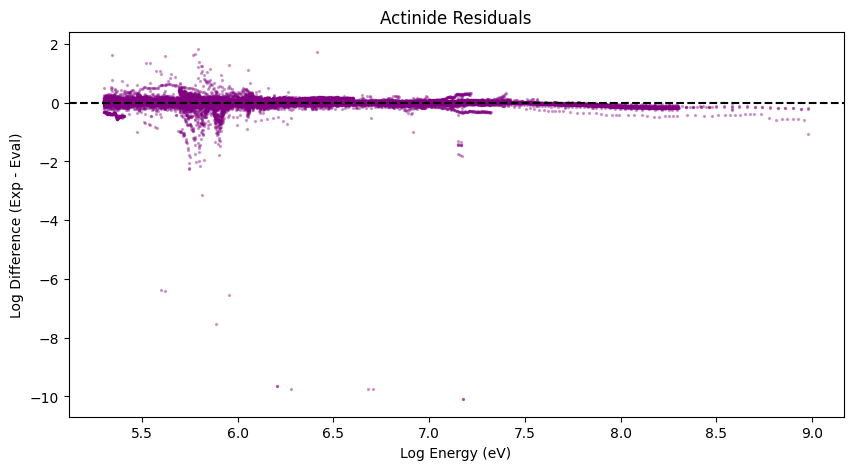

In [3]:
print("Calculating Residuals across all Actinides...")

all_residuals = []

# Loop through each isotope to calculate its specific residuals
for iso in df_ml['Isotope'].unique():
    try:
        # 1. Isolate experimental data for this isotope
        df_iso_exp = df_ml[df_ml['Isotope'] == iso].copy()
        
        # 2. Load the corresponding ENDF evaluation
        df_eval = nuc_data.load_evaluation(iso.lower(), 18, library='endfb8.0')
        
        # Handle Log scales (standardize to Log10 for interpolation)
        e_eval = df_eval['Energy'] if df_eval['Energy'].max() < 100 else np.log10(df_eval['Energy'])
        d_eval = df_eval['Data'] if df_eval['Data'].max() < 10 else np.log10(df_eval['Data'] + 1e-10)
        
        e_exp_log = np.log10(df_iso_exp[energy_col])
        d_exp_log = np.log10(df_iso_exp[target] + 1e-10)

        # 3. Interpolate Evaluated curve onto Experimental Energy points
        # "What did ENDF think the value was at this exact experimental energy?"
        interp_vals = np.interp(e_exp_log, e_eval, d_eval)

        # 4. Calculate the Residual (Log Difference)
        df_iso_exp['residual'] = d_exp_log - interp_vals
        
        # 5. Add Physics Context (Magic Numbers & Shell Effects)
        df_iso_exp['N'] = df_iso_exp['A'] - df_iso_exp['Z']
        df_iso_exp['magic_dist'] = abs(df_iso_exp['N'] - 126) # Distance to N=126 shell
        
        all_residuals.append(df_iso_exp)
    except Exception as e:
        print(f"Skipping {iso}: {e}")

# Recombine into a single training dataframe
df_res_final = pd.concat(all_residuals)
print(f"Residual Data Prepared with {len(df_res_final)} rows across {len(all_residuals)} isotopes.")

# Plot Residuals to verify they are centered near 0
plt.figure(figsize=(10, 5))
plt.scatter(np.log10(df_res_final[energy_col]), df_res_final['residual'], s=2, alpha=0.3, color='purple')
plt.axhline(0, color='k', linestyle='--')
plt.title("Actinide Residuals")
plt.ylabel("Log Difference (Exp - Eval)")
plt.xlabel("Log Energy (eV)")
plt.show()

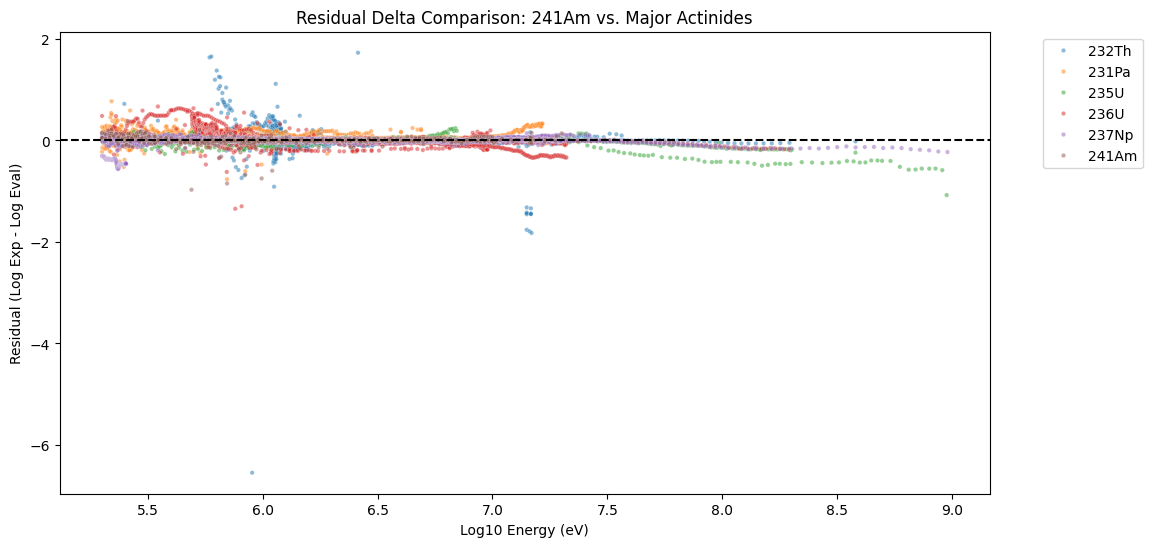

In [9]:
import seaborn as sns

# 1. Identify Top 5 isotopes by data point count for a clean plot
top_isos = df_res_final['Isotope'].value_counts().nlargest(5).index.tolist()
if target_iso not in top_isos:
    top_isos.append(target_iso)

plot_df = df_res_final[df_res_final['Isotope'].isin(top_isos)]

# 2. Plotting Residual Comparison
plt.figure(figsize=(12, 6))
sns.scatterplot(data=plot_df, x=np.log10(plot_df[energy_col]), y='residual', 
                hue='Isotope', alpha=0.5, s=10)
plt.axhline(0, color='black', linestyle='--')
plt.title(f"Residual Delta Comparison: {target_iso} vs. Major Actinides")
plt.xlabel("Log10 Energy (eV)")
plt.ylabel("Residual (Log Exp - Log Eval)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [5]:
# 1. Prepare Training Data (Leave-One-Out)
# We exclude Am-241 so we can test the "correction" on an unseen isotope
train_data = df_res_final[df_res_final['Isotope'] != target_iso].copy()

# Select only the features you defined
features_res = [energy_col, 'Z', 'A', 'N', 'magic_dist', 'Binding_Energy_exfor', 'S(n)_exfor', 'Level_Number']
train_subset = train_data[features_res + ['residual']]

print(f"Training AutoGluon on {len(train_subset)} points...")

# 2. Fit AutoGluon
predictor_res = TabularPredictor(label='residual', eval_metric='mean_absolute_error').fit(
    train_subset, 
    presets='best_quality', 
    time_limit=600
)

No path specified. Models will be saved in: "AutogluonModels/ag-20260213_105447"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.10.19
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 25.2.0: Tue Nov 18 21:09:40 PST 2025; root:xnu-12377.61.12~1/RELEASE_ARM64_T6000
CPU Count:          8
Memory Avail:       4.13 GB / 16.00 GB (25.8%)
Disk Space Avail:   276.95 GB / 460.43 GB (60.2%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking a

Training AutoGluon on 32360 points...


2026-02-13 10:54:48,166	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
	Running DyStack sub-fit in a ray process to avoid memory leakage. Enabling ray logging (enable_ray_logging=True). Specify `ds_args={'enable_ray_logging': False}` if you experience logging issues.
2026-02-13 10:54:51,150	INFO worker.py:1843 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8266 
		Context path: "/Users/glsw/main/AutogluonModels/ag-20260213_105447/ds_sub_fit/sub_fit_ho"
(_dystack pid=40028) Running DyStack sub-fit ...
(_dystack pid=40028) Beginning AutoGluon training ... Time limit = 146s
(_dystack pid=40028) AutoGluon will save models to "/Users/glsw/main/AutogluonModels/ag-20260213_105447/ds_sub_fit/sub_fit_ho"
(_dystack pid=40028) Train Data Rows:    28764
(_dystack pid=40028) Train Data Columns: 8
(_dystack pid=40028) Label Column:       residual
(_dystack pid=40028) Problem Type:    

(_ray_fit pid=40045) [1000]	valid_set's l1: 0.0434244
(_ray_fit pid=40042) [4000]	valid_set's l1: 0.0448572 [repeated 23x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(_ray_fit pid=40042) [8000]	valid_set's l1: 0.0447825 [repeated 17x across cluster]


(_dystack pid=40028) 	-0.045	 = Validation score   (-mean_absolute_error)
(_dystack pid=40028) 	16.56s	 = Training   runtime
(_dystack pid=40028) 	19.66s	 = Validation runtime
(_dystack pid=40028) Fitting model: LightGBM_BAG_L1 ... Training model for up to 69.25s of the 117.82s of remaining time.
(_dystack pid=40028) 	Fitting 8 child models (S1F1 - S1F8) | Fitting with ParallelLocalFoldFittingStrategy (8 workers, per: cpus=1, gpus=0, memory=0.35%)
(_dystack pid=40028) 	-0.0449	 = Validation score   (-mean_absolute_error)
(_dystack pid=40028) 	1.13s	 = Training   runtime
(_dystack pid=40028) 	0.54s	 = Validation runtime
(_dystack pid=40028) Fitting model: RandomForestMSE_BAG_L1 ... Training model for up to 65.56s of the 114.13s of remaining time.
(_dystack pid=40028) 	-0.0539	 = Validation score   (-mean_absolute_error)
(_dystack pid=40028) 	3.32s	 = Training   runtime
(_dystack pid=40028) 	1.08s	 = Validation runtime
(_dystack pid=40028) Fitting model: CatBoost_BAG_L1 ... Training mode

>>> Step 5: Visualizing ML-Corrected Evaluation vs Benchmarks...


INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am241/endfb8.0/tables/xs/n-Am241-MT018.endfb8.0
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
INFO:root:EVALUATION: Finished. ENDF data contains 16294 datapoints.
INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am241/tendl.2019/tables/xs/n-Am241-MT018.tendl.2019
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future ver

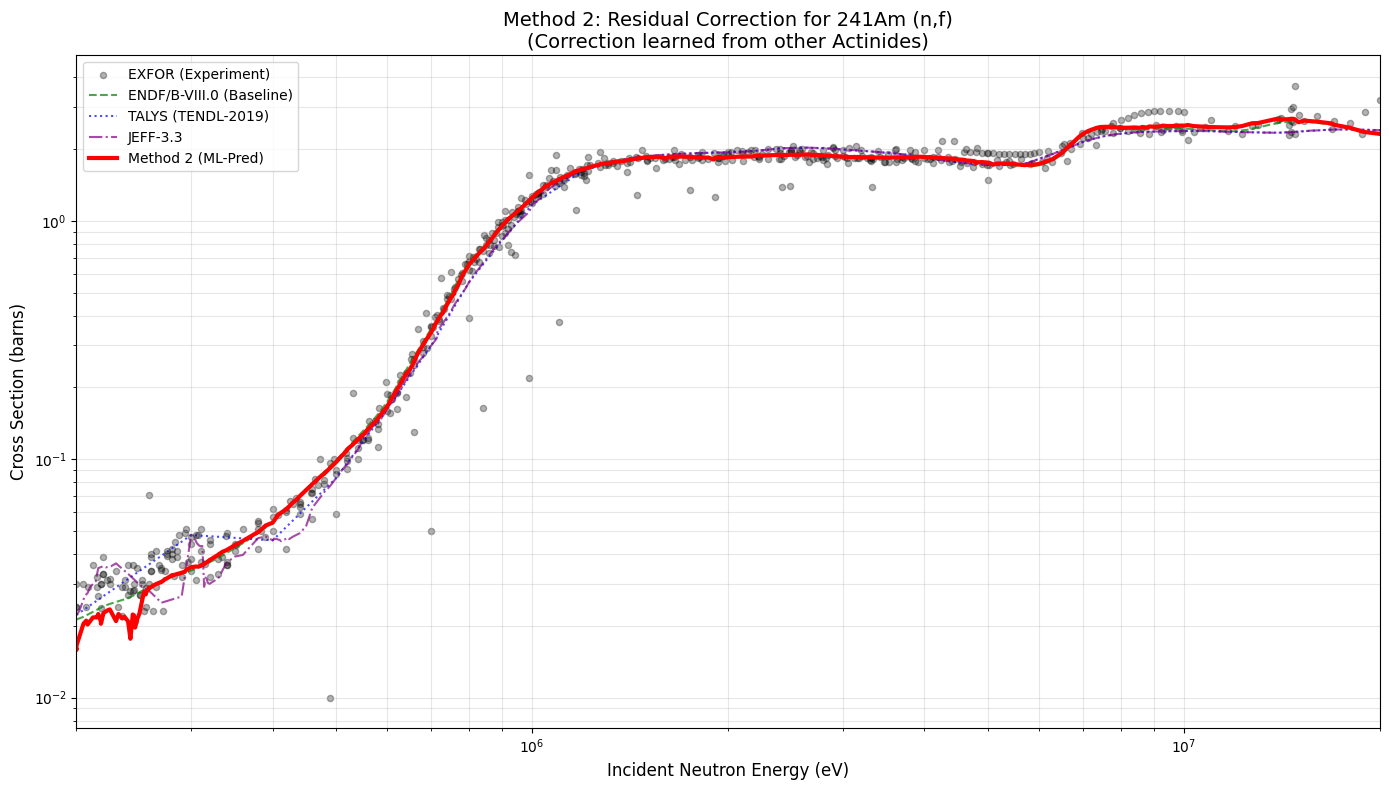

In [6]:
# ==========================================
# 7. ANALYSIS & VISUALIZATION (METHOD 2)
# ==========================================
print(">>> Step 5: Visualizing ML-Corrected Evaluation vs Benchmarks...")

# 1. Prepare Am-241 test features
test_iso_df = df_res_final[df_res_final['Isotope'] == target_iso].copy()
test_features = test_iso_df[features_res]

# 2. Predict the Correction (Residual)
test_iso_df['predicted_residual'] = predictor_res.predict(test_features)

# 3. Apply Correction to the original ENDF curve
# Corrected = 10^(Log10(Original) + Prediction)
# Note: Residuals were calculated as (LogExp - LogEval)
test_iso_df['ML_Corrected'] = 10**(np.log10(test_iso_df['Data'] / (10**test_iso_df['residual'])) + test_iso_df['predicted_residual'])

# 4. Setup Plot
plt.figure(figsize=(14, 8))

# 5. Plot Experimental Data (EXFOR)
plt.scatter(test_iso_df[energy_col], test_iso_df['Data'], color='black', s=20, alpha=0.3, label='EXFOR (Experiment)')

# --- HELPER FUNCTION FOR OVERLAYING LIBRARIES ---
def overlay_library(iso, mt, lib, color, style, label):
    try:
        df = nuc_data.load_evaluation(iso, mt, library=lib)
        if not df.empty:
            e = 10**df['Energy'] if df['Energy'].max() < 100 else df['Energy']
            d = 10**df['Data'] if df['Data'].max() < 10 else df['Data']
            mask = e >= 2e5 # Fast Regime only
            plt.plot(e[mask], d[mask], color=color, linestyle=style, linewidth=1.5, label=label, alpha=0.7)
    except:
        pass

# 6. Plot Benchmark Libraries
overlay_library("am241", 18, "endfb8.0", "green", "--", "ENDF/B-VIII.0 (Baseline)")
overlay_library("am241", 18, "tendl.2019", "blue", ":", "TALYS (TENDL-2019)")
overlay_library("am241", 18, "jeff3.3", "purple", "-.", "JEFF-3.3")

# 7. Plot Your ML-Corrected Evaluation
sort_idx = np.argsort(test_iso_df[energy_col].values)
plt.plot(test_iso_df[energy_col].values[sort_idx], test_iso_df['ML_Corrected'].values[sort_idx], 
         color='red', linewidth=3, label='Method 2 (ML-Pred)')

# 8. Final Formatting
plt.xscale('log'); plt.yscale('log')
plt.xlim(2e5, 2e7)
plt.xlabel('Incident Neutron Energy (eV)', fontsize=12)
plt.ylabel('Cross Section (barns)', fontsize=12)
plt.title(f'Method 2: Residual Correction for {target_iso} (n,f)\n(Correction learned from other Actinides)', fontsize=14)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

>>> Executing Method 2: Residual Correction Analysis...


INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am241/endfb8.0/tables/xs/n-Am241-MT018.endfb8.0
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
INFO:root:EVALUATION: Finished. ENDF data contains 16294 datapoints.
INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am241/tendl.2019/tables/xs/n-Am241-MT018.tendl.2019
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future ver

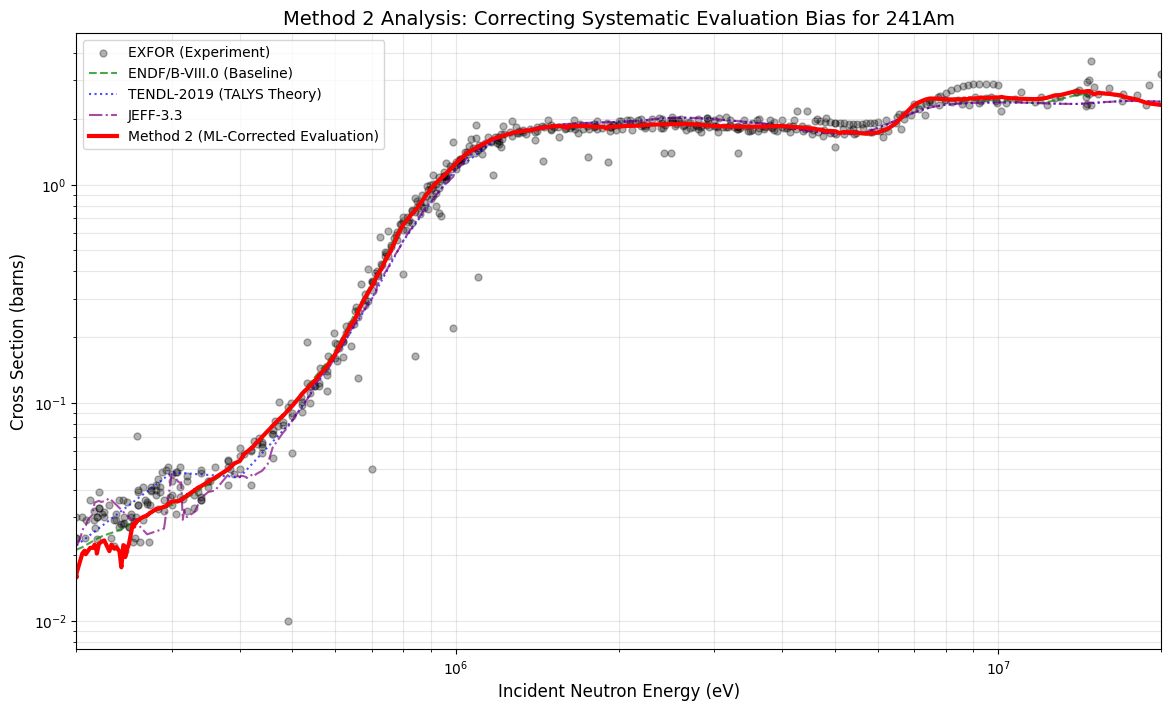

Original Evaluation Error (Log-MAE): 0.0442
ML-Corrected Evaluation Error (Log-MAE): 0.0474
Total Bias Reduction: -7.39%


In [7]:
# ==========================================
# 7. FINAL METHOD 2 ANALYSIS & PLOT
# ==========================================
print(">>> Executing Method 2: Residual Correction Analysis...")

# 1. Predict correction for Am-241
test_iso_df = df_res_final[df_res_final['Isotope'] == target_iso].copy()
test_iso_df['predicted_residual'] = predictor_res.predict(test_iso_df[features_res])

# 2. Reconstruct ML-Corrected Curve
# Note: original_endf is recovered from the inverse of your residual calc
test_iso_df['Original_ENDF'] = 10**(np.log10(test_iso_df[target]) - test_iso_df['residual'])
test_iso_df['ML_Corrected'] = 10**(np.log10(test_iso_df['Original_ENDF']) + test_iso_df['predicted_residual'])

# 3. Visualization
plt.figure(figsize=(14, 8))
plt.scatter(test_iso_df[energy_col], test_iso_df[target], color='black', s=25, alpha=0.3, label='EXFOR (Experiment)')

# Plot Benchmarks
overlay_library("am241", 18, "endfb8.0", "green", "--", "ENDF/B-VIII.0 (Baseline)")
overlay_library("am241", 18, "tendl.2019", "blue", ":", "TENDL-2019 (TALYS Theory)")
overlay_library("am241", 18, "jeff3.3", "purple", "-.", "JEFF-3.3")

# Plot Method 2 Correction
sort_idx = np.argsort(test_iso_df[energy_col].values)
plt.plot(test_iso_df[energy_col].values[sort_idx], test_iso_df['ML_Corrected'].values[sort_idx], 
         color='red', linewidth=3, label='Method 2 (ML-Corrected Evaluation)')

# Formatting
plt.xscale('log'); plt.yscale('log'); plt.xlim(2e5, 2e7)
plt.xlabel('Incident Neutron Energy (eV)', fontsize=12); plt.ylabel('Cross Section (barns)', fontsize=12)
plt.title(f'Method 2 Analysis: Correcting Systematic Evaluation Bias for {target_iso}', fontsize=14)
plt.legend(loc='upper left', fontsize=10); plt.grid(True, which="both", alpha=0.3)
plt.show()

# Quantitative Improvement Check
original_mae = np.mean(abs(test_iso_df['residual']))
corrected_mae = np.mean(abs(test_iso_df['residual'] - test_iso_df['predicted_residual']))
print(f"Original Evaluation Error (Log-MAE): {original_mae:.4f}")
print(f"ML-Corrected Evaluation Error (Log-MAE): {corrected_mae:.4f}")
print(f"Total Bias Reduction: {((original_mae - corrected_mae) / original_mae)*100:.2f}%")

Computing feature importance via permutation shuffling for 8 features using 573 rows with 5 shuffle sets...


>>> Calculating Feature Importance for 241Am residuals...


	108.17s	= Expected runtime (21.63s per shuffle set)
	36.53s	= Actual runtime (Completed 5 of 5 shuffle sets)


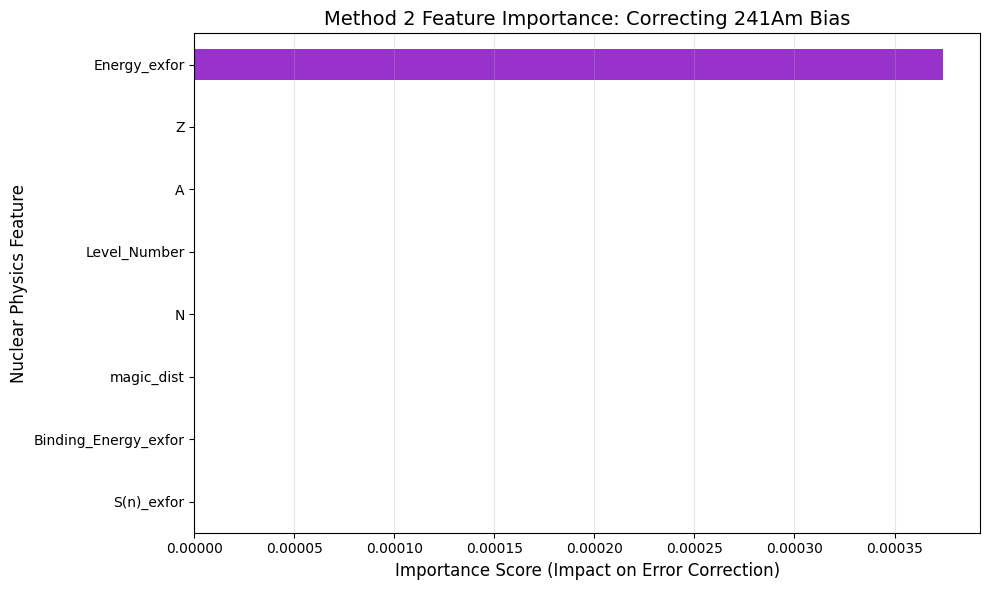

                        importance    stddev   p_value  n      p99_high  \
Energy_exfor          3.740196e-04  0.001121  0.248479  5  2.681417e-03   
Z                    -1.173296e-11  0.000000  0.500000  5 -1.173296e-11   
A                    -1.142821e-10  0.000000  0.500000  5 -1.142821e-10   
Level_Number         -8.134343e-10  0.000000  0.500000  5 -8.134343e-10   
N                    -1.017415e-09  0.000000  0.500000  5 -1.017415e-09   
magic_dist           -1.309774e-09  0.000000  0.500000  5 -1.309774e-09   
Binding_Energy_exfor -1.607314e-09  0.000000  0.500000  5 -1.607314e-09   
S(n)_exfor           -1.709914e-09  0.000000  0.500000  5 -1.709914e-09   

                           p99_low  
Energy_exfor         -1.933378e-03  
Z                    -1.173296e-11  
A                    -1.142821e-10  
Level_Number         -8.134343e-10  
N                    -1.017415e-09  
magic_dist           -1.309774e-09  
Binding_Energy_exfor -1.607314e-09  
S(n)_exfor           -1.7099

In [8]:
# ==========================================
# 8. FEATURE IMPORTANCE (RESIDUAL METHOD)
# ==========================================
print(f">>> Calculating Feature Importance for {target_iso} residuals...")

# 1. Identify the correct test data from your Method 2 notebook
# In Method 2, we use the Am-241 specific dataframe created for prediction
if 'test_iso_df' in locals():
    importance_test_data = test_iso_df[features_res + ['residual']]
elif 'test_subset' in locals():
    importance_test_data = test_subset
else:
    # Fallback: Re-create it if it was dropped
    importance_test_data = df_res_final[df_res_final['Isotope'] == target_iso][features_res + ['residual']]

# 2. Calculate Importance
importance = predictor_res.feature_importance(importance_test_data)

# 3. Plotting
plt.figure(figsize=(10, 6))
importance['importance'].sort_values().plot(kind='barh', color='darkorchid')
plt.title(f'Method 2 Feature Importance: Correcting {target_iso} Bias', fontsize=14)
plt.xlabel('Importance Score (Impact on Error Correction)', fontsize=12)
plt.ylabel('Nuclear Physics Feature', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(importance)